# 1.import required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve

# 2.Data Generation and Experiment Setup

In [2]:
# Set a fixed random seed for reproducibility
SEED = 42
rng = np.random.default_rng(SEED)
np.random.seed(SEED)
# Define dataset sizes
N = 100
n_train = 15
# Define input domain range
x_min, x_max = 0.0, 1.0
# List of model complexities to evaluate
M_list = [1, 3, 5, 9, 11, 13, 15]
# Noise configuration
noise_std = 0.05
beta = 1.0 / (noise_std ** 2)
# Fixed regularization parameter
alpha_star_fixed = 0.01
# Generate full input grid
x_all = np.linspace(x_min, x_max, N)
# Define the true underlying function
f_true_all = 20 * x_all * np.exp(-7 * x_all)
# Generate noisy observations
t_all = f_true_all + noise_std * rng.normal(size=N)
# Select training input points
x_train = np.linspace(x_min, x_max, n_train)
# Indices of training samples
idx_train = np.linspace(0, N - 1, n_train, dtype=int)
# Training targets
t_train = t_all[idx_train]
# Indices of test samples
idx_test = np.setdiff1d(np.arange(N), idx_train)
# Test inputs
x_test = x_all[idx_test]
# Test targets
t_test = t_all[idx_test]

# 3. Defining the Ground-Truth Function
Define the true underlying function used to generate target values

In [3]:
def f_true(x: np.ndarray) -> np.ndarray:
    return 20 * x * np.exp(-7 * x)

# 4. Mean Squared Error Utility Function
Compute the mean squared error between predictions and true targets

In [4]:
def mse(y_pred: np.ndarray, y_true: np.ndarray) -> float:
    y_pred = np.asarray(y_pred).ravel()
    y_true = np.asarray(y_true).ravel()
    return float(np.mean((y_pred - y_true)**2))

# 5. Polynomial Design Matrix Construction
Build a polynomial design matrix using powers of the input variable

In [5]:
def design_matrix_poly(x: np.ndarray, M: int) -> np.ndarray:
    return np.vander(x, M+1, increasing=True)

# 6. Gaussian Basis Design Matrix Construction

In [6]:
# Build a design matrix using Gaussian basis functions
def design_matrix_gauss(
    x: np.ndarray,
    M: int,
    centers: np.ndarray = None,
    sigma: float = None,
    include_bias: bool = True
) -> tuple:
    # Initialize Gaussian centers if not provided
    if centers is None:
        centers = np.linspace(x_min, x_max, M)
    # Set the Gaussian width (sigma) if not provided
    if sigma is None:
        sigma = (x_max - x_min) / (M - 1) if M > 1 else 0.1
    # Compute the Gaussian basis function values
    Phi = np.exp(-0.5 * ((x[:, None] - centers[None, :]) / sigma) ** 2)
    # Optionally add a bias (constant) term to the design matrix
    if include_bias:
        Phi = np.c_[np.ones_like(x), Phi]
    return Phi, centers, sigma

# 7. Least Squares Model Fitting
Fit model parameters using the closed-form least squares solution

In [7]:
def fit_ls(Phi: np.ndarray, t: np.ndarray) -> np.ndarray:
    return solve(Phi.T @ Phi, Phi.T @ t)

# 8. MAP Estimation for Linear Regression
Fit model parameters using MAP estimation with Gaussian prior

In [8]:
def fit_map(Phi: np.ndarray, t: np.ndarray, alpha: float, beta: float) -> np.ndarray:
    n_features = Phi.shape[1]
    return solve(beta * (Phi.T @ Phi) + alpha * np.eye(n_features), beta * (Phi.T @ t))

# 9. Plotting Model Fits and Predictions

In [9]:
# Visualize model predictions along with true function and data points
def plot_fits(models: dict, basis_type: str, title: str):
    # Create a dense input grid for smooth curves
    x_fine = np.linspace(x_min, x_max, 200)
    # Initialize the figure
    plt.figure(figsize=(10, 6))
    # Plot predictions for each model complexity
    for M, (w, params) in models.items():
        # Build the appropriate design matrix based on basis type
        if basis_type == "poly":
            Phi_fine = design_matrix_poly(x_fine, M)
        else:
            centers, sigma = params
            Phi_fine, _, _ = design_matrix_gauss(
                x_fine, M, centers=centers, sigma=sigma, include_bias=True
            )
        # Compute model predictions
        y_fine = Phi_fine @ w
        # Plot the predicted curve
        plt.plot(x_fine, y_fine, label=f'M={M}')
    # Plot the true underlying function
    plt.plot(x_all, f_true_all, 'k--', label='True f(x)')
    # Plot training data points
    plt.scatter(x_train, t_train, color='r', s=20, label='Train')
    # Plot test data points
    plt.scatter(x_test, t_test, color='g', s=10, alpha=0.5, label='Test')
    # Configure plot labels and appearance
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# 10. Visualizing Model Weights as a Heatmap

In [10]:
# Plot a heatmap of learned weights across different model complexities
def plot_weight_heatmap(w_dict: dict, M_list: list, title: str):
    # Determine the maximum number of basis functions
    max_M = max(M_list)
    # Initialize the weight matrix for visualization
    W_mat = np.zeros((max_M + 1, len(M_list)))
    # Populate the matrix with weights for each model
    for i, M in enumerate(M_list):
        w = w_dict[M]
        W_mat[:len(w), i] = w
    # Create the heatmap figure
    plt.figure(figsize=(8, 6))
    plt.imshow(W_mat, aspect='auto', cmap='RdBu')
    plt.colorbar(label='w_j')
    # Configure plot labels and ticks
    plt.xlabel('M index')
    plt.ylabel('Basis index j')
    plt.title(title)
    plt.xticks(np.arange(len(M_list)), M_list)
    plt.show()

# 11. Plotting Weight Norms Across Model Complexity

In [11]:
# Plot the L2 norm of model weights as a function of model complexity
def plot_weight_norms(w_dict: dict, M_list: list, title: str):
    # Compute L2 norms of the weight vectors
    norms = [np.linalg.norm(w_dict[M]) for M in M_list]
    # Create the figure
    plt.figure(figsize=(7, 5))
    # Plot norms versus model complexity
    plt.plot(M_list, norms, marker='o')
    # Configure plot labels and appearance
    plt.xlabel('M')
    plt.ylabel('||w||_2')
    plt.title(title)
    plt.grid(True)
    plt.show()

# 12. Plotting the Regularized MSE Energy Surface (Contour Plot)

In [12]:
# Plot a 2D contour of the regularized MSE objective around the MAP solution
def plot_mse_surface(
    Phi: np.ndarray,
    t: np.ndarray,
    w_opt: np.ndarray,
    alpha: float,
    beta: float,
    M: int = None,
    title_suffix: str = ''
):
    # If the model has more than 2 parameters, vary only (w0, w1) and keep the rest fixed
    if M > 2:
        w_fixed = w_opt.copy()
        # Energy function slice over the first two weights
        def E_slice(w_slice):
            w = w_fixed.copy()
            w[:2] = w_slice
            y_pred = Phi @ w
            return 0.5 * beta * np.mean((t - y_pred) ** 2) + 0.5 * alpha * np.linalg.norm(w) ** 2
        # Build a grid centered around the MAP weights (w0, w1)
        w1_grid, w2_grid = np.meshgrid(
            np.linspace(w_opt[0] - 1, w_opt[0] + 1, 50),
            np.linspace(w_opt[1] - 1, w_opt[1] + 1, 50)
        )
        # Evaluate energy values on the grid
        E_grid = np.vectorize(lambda w1, w2: E_slice([w1, w2]))(w1_grid, w2_grid)
    # For small M, directly visualize the full 2D surface over (w0, w1)
    else:
        # Use a broader range when we only have a 2D view
        w1_grid, w2_grid = np.meshgrid(np.linspace(-5, 5, 50), np.linspace(-5, 5, 50))
        # Energy function for the displayed weight pair (with the remaining terms handled safely)
        def E_full(w1, w2):
            w = np.array([w1, w2]) if M == 1 else np.array([w1, w2] + list(w_opt[2:]))
            y_pred = Phi @ w[:M + 1]
            return 0.5 * beta * np.mean((t - y_pred) ** 2) + 0.5 * alpha * np.linalg.norm(w[:M + 1]) ** 2
        # Evaluate energy values on the grid
        E_grid = np.vectorize(E_full)(w1_grid, w2_grid)
    # Create the contour plot
    plt.figure(figsize=(8, 6))
    contours = plt.contourf(w1_grid, w2_grid, E_grid, levels=20, cmap='viridis')
    plt.colorbar(contours, label='E(w) (log-posterior, up to const)')
    # Mark the MAP solution on the plot
    plt.plot(w_opt[0], w_opt[1], 'r*', markersize=15, label='w_MAP')
    # Configure plot labels and appearance
    plt.xlabel('w0')
    plt.ylabel('w1')
    plt.title(f'MSE(w) Contour | M={M} {title_suffix}')
    plt.legend()
    plt.grid(True)
    plt.show()

# 13. Running Least Squares Fits for a Given Basis Type

In [13]:
# Train least squares models for each M and return train/test MSEs plus fitted weights
def run_ls_for_basis(basis_type: str):
    # Containers for metrics and learned parameters
    train_mses, test_mses = [], []
    w_ls = {}
    basis_params = {}
    # Loop over different model complexities
    for M in M_list:
        # Build design matrices depending on the chosen basis
        if basis_type == "poly":
            Phi_tr = design_matrix_poly(x_train, M)
            Phi_te = design_matrix_poly(x_test, M)
            params = None
        else:
            Phi_tr, centers, sigma = design_matrix_gauss(x_train, M, include_bias=True)
            Phi_te, _, _ = design_matrix_gauss(
                x_test, M, centers=centers, sigma=sigma, include_bias=True
            )
            params = (centers, sigma)
        # Fit least squares weights
        w = fit_ls(Phi_tr, t_train)
        # Compute predictions on train and test sets
        y_tr = Phi_tr @ w
        y_te = Phi_te @ w
        # Track performance using MSE
        train_mses.append(mse(y_tr, t_train))
        test_mses.append(mse(y_te, t_test))
        # Store weights and any basis-specific parameters (e.g., centers/sigma)
        w_ls[M] = w
        basis_params[M] = params
    return np.array(train_mses), np.array(test_mses), w_ls, basis_params

# 14. Selecting Optimal and Overfitting Model Complexity

In [14]:
# Identify the best M based on test MSE and a heuristic overfitting point
def choose_M_overfit(train_mses: np.ndarray, test_mses: np.ndarray):
    # Index of the model with minimum test error
    idx_opt = int(np.argmin(test_mses))
    M_opt = M_list[idx_opt]
    best_test = float(test_mses[idx_opt])
    # Initialize overfitting model selection
    M_overfit = None
    # Search for the point where training error decreases but test error worsens
    for i in range(idx_opt + 1, len(M_list)):
        if (train_mses[i] < train_mses[i - 1]) and (test_mses[i] > best_test):
            M_overfit = M_list[i]
            break
    # Fallback to the largest model if no clear overfitting point is found
    if M_overfit is None:
        M_overfit = M_list[-1]
    return M_opt, M_overfit

# 15. Running MAP Estimation for a Given Basis Type

In [15]:
# Train MAP-regularized models for each M using a fixed alpha value
def run_map_for_basis(
    basis_type: str,
    M_overfit: int,
    basis_params: dict,
    alpha_star: float,
    beta: float
):
    # Containers for metrics and learned weights
    train_mses, test_mses = [], []
    w_map = {}
    # Loop over different model complexities
    for M in M_list:
        # Build design matrices depending on the chosen basis
        if basis_type == "poly":
            Phi_tr = design_matrix_poly(x_train, M)
            Phi_te = design_matrix_poly(x_test, M)
        else:
            centers, sigma = basis_params[M]
            Phi_tr, _, _ = design_matrix_gauss(
                x_train, M, centers=centers, sigma=sigma, include_bias=True
            )
            Phi_te, _, _ = design_matrix_gauss(
                x_test, M, centers=centers, sigma=sigma, include_bias=True
            )
        # Fit MAP weights with fixed regularization strength
        w = fit_map(Phi_tr, t_train, alpha_star, beta)
        # Compute predictions on train and test sets
        y_tr = Phi_tr @ w
        y_te = Phi_te @ w
        # Track performance using MSE
        train_mses.append(mse(y_tr, t_train))
        test_mses.append(mse(y_te, t_test))
        # Store learned weights
        w_map[M] = w
    return alpha_star, np.array(train_mses), np.array(test_mses), w_map

# 16. Initializing Result Storage and Reporting Hyperparameters

In [16]:
# Initialize a container to store all experiment results
all_results = {}
# Print key hyperparameters for reference and reproducibility
print(f"β (noise precision) = {beta:.2f} | α* (fixed) = {alpha_star_fixed:.2e} | λ = α*/β = {alpha_star_fixed / beta:.2e}")

β (noise precision) = 400.00 | α* (fixed) = 1.00e-02 | λ = α*/β = 2.50e-05


# 17. Running LS vs MAP Experiments Across Polynomial and Gaussian Bases

c:\Users\Mahdie\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=6.73328e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\Mahdie\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.1341e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
c:\Users\Mahdie\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=1.64537e-19): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


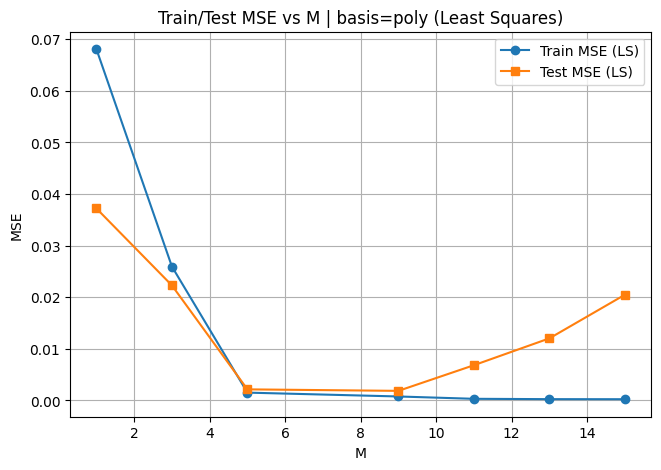

[basis=poly] M_opt (min Test LS) = 9 | M_overfit = 11


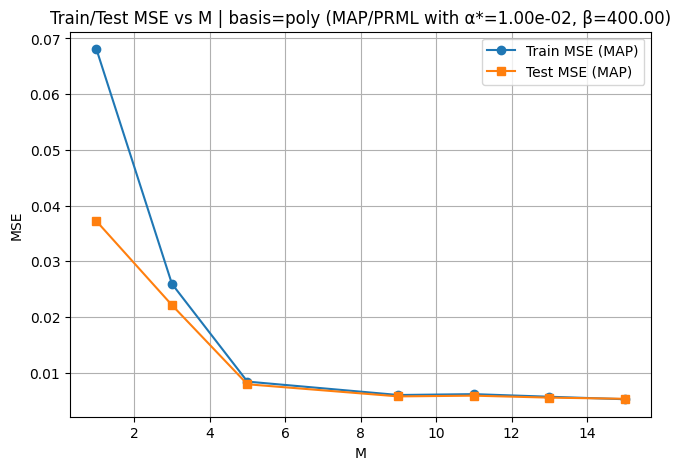

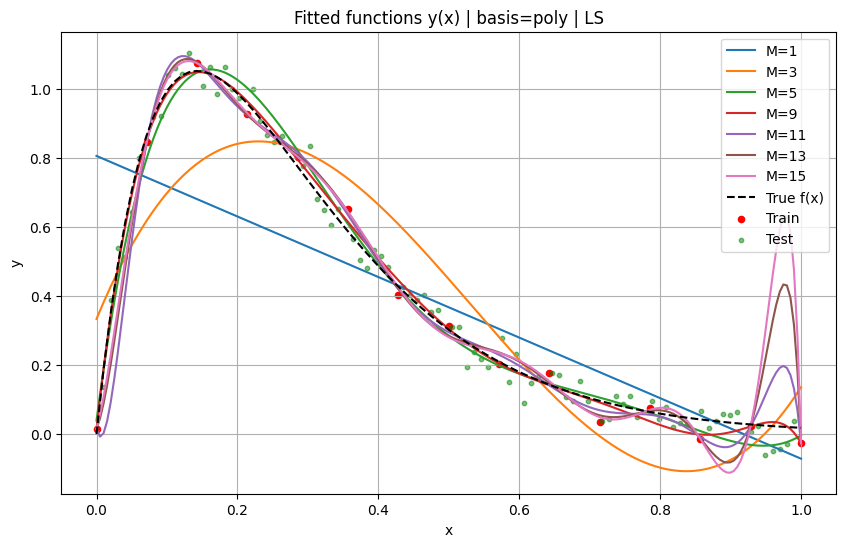

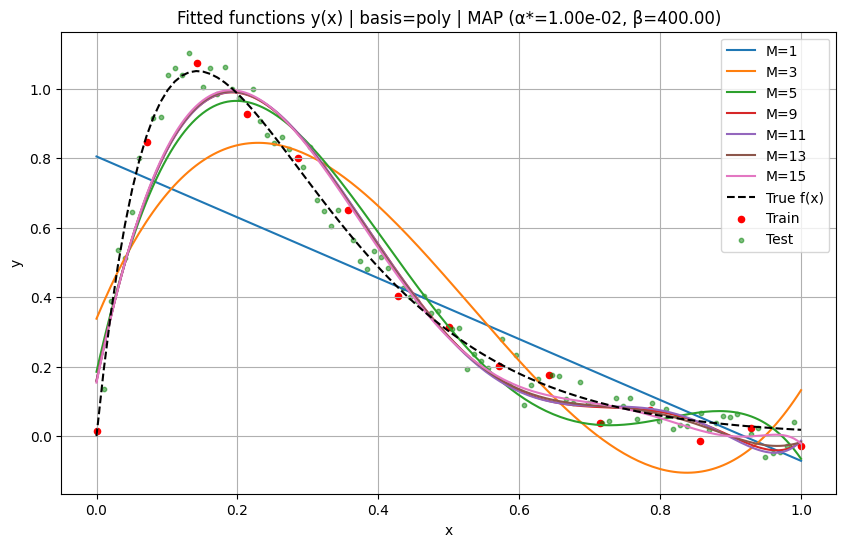

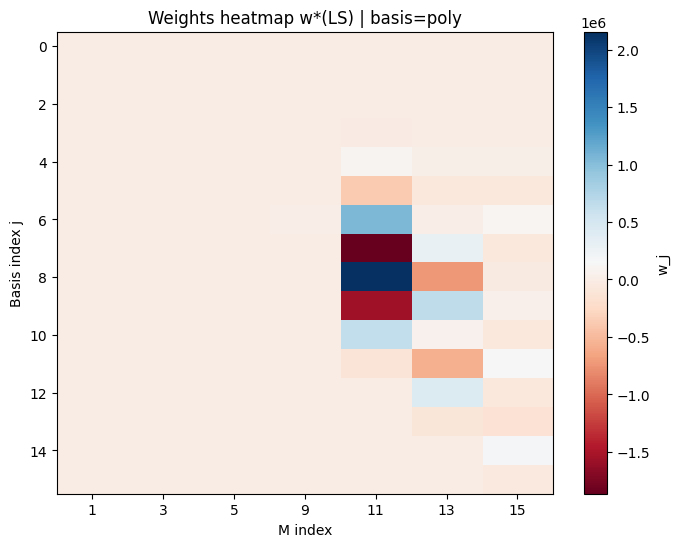

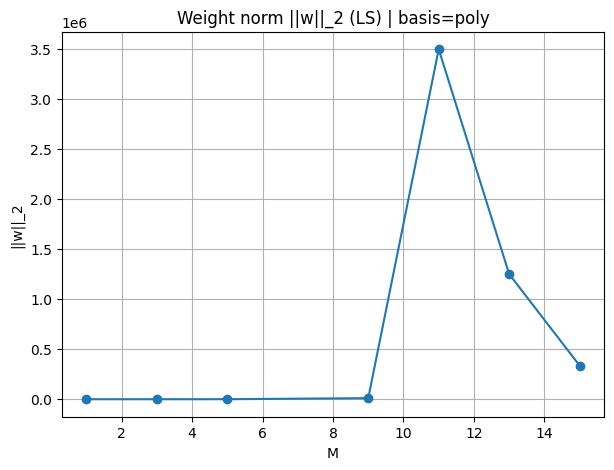

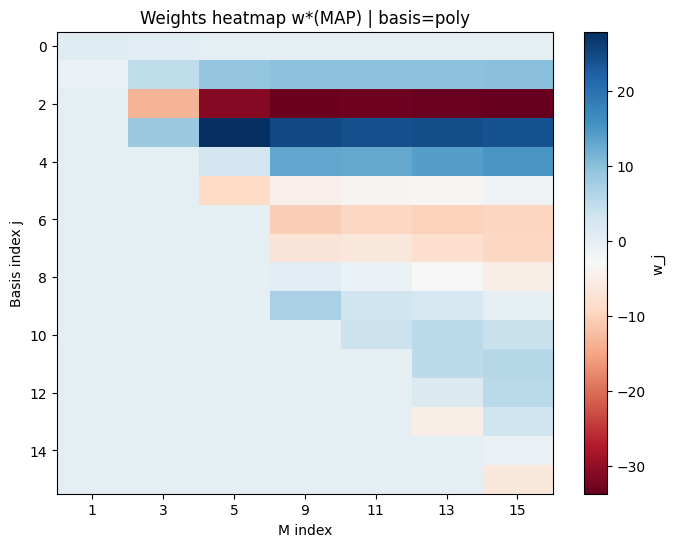

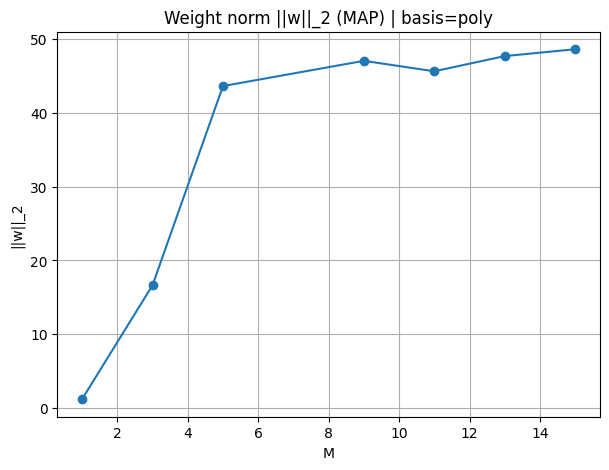

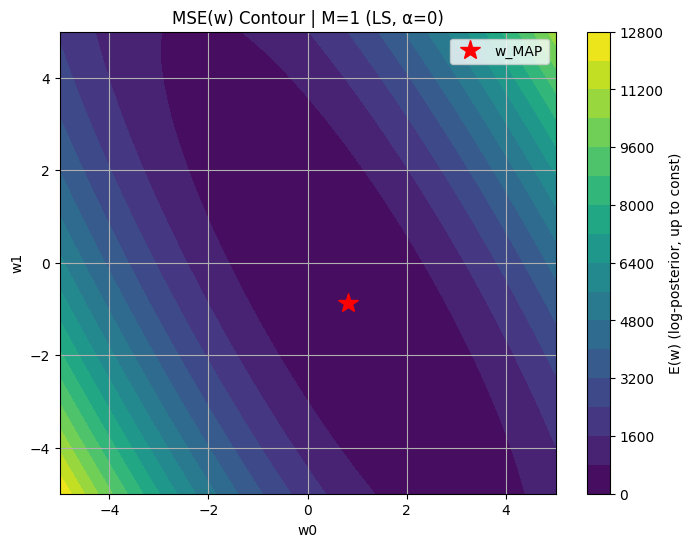

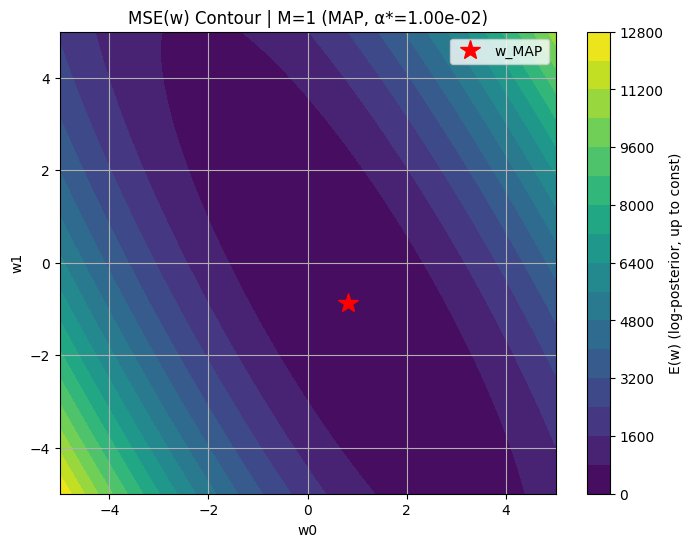

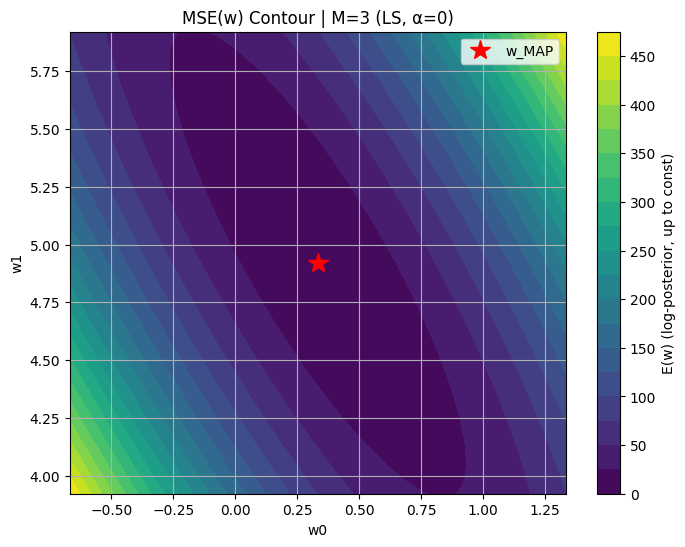

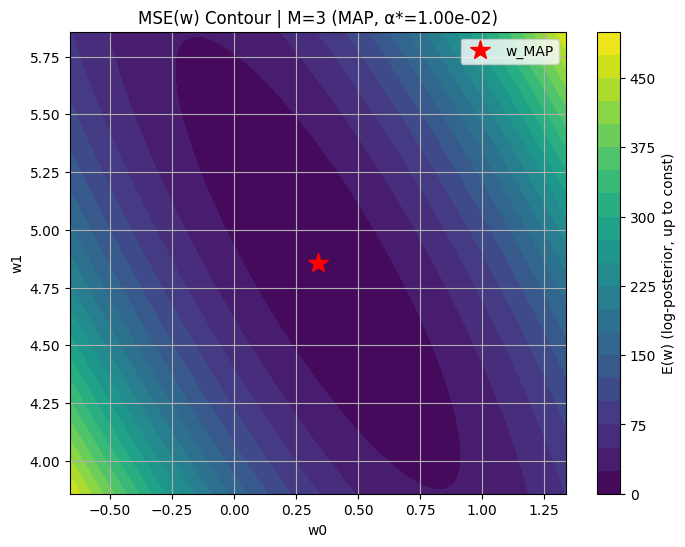

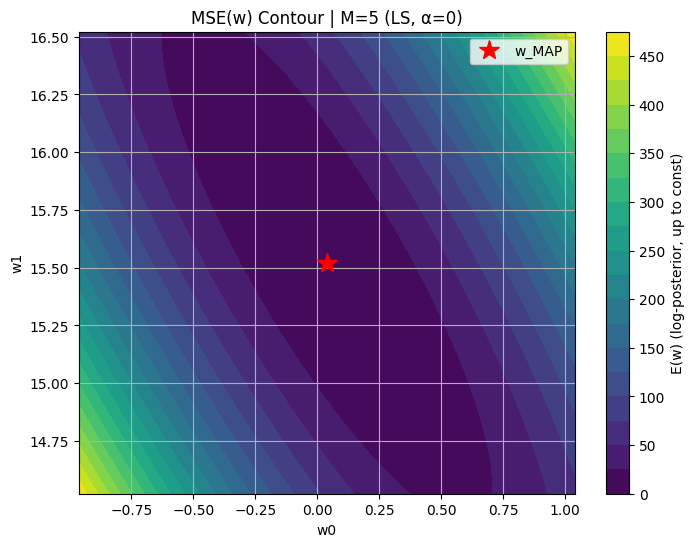

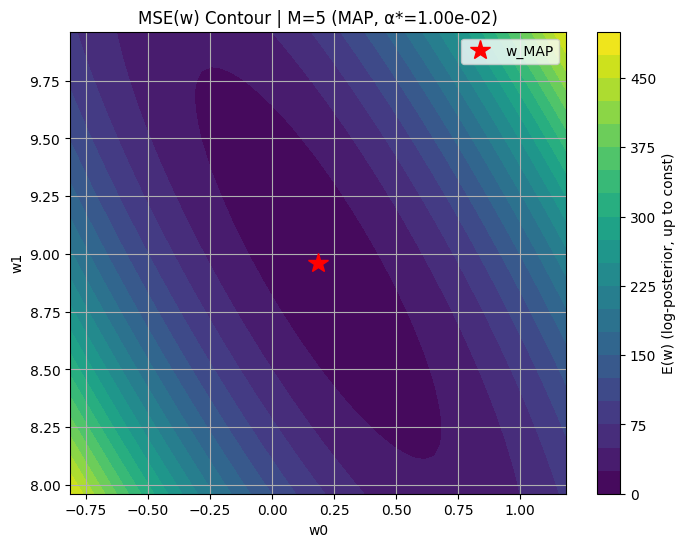

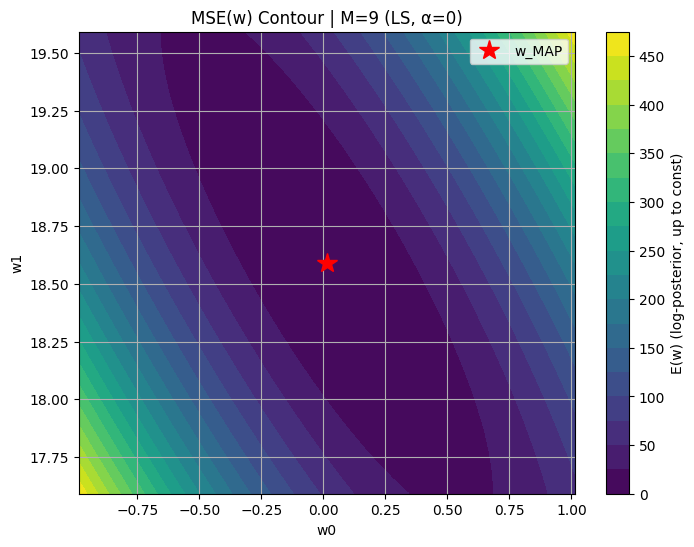

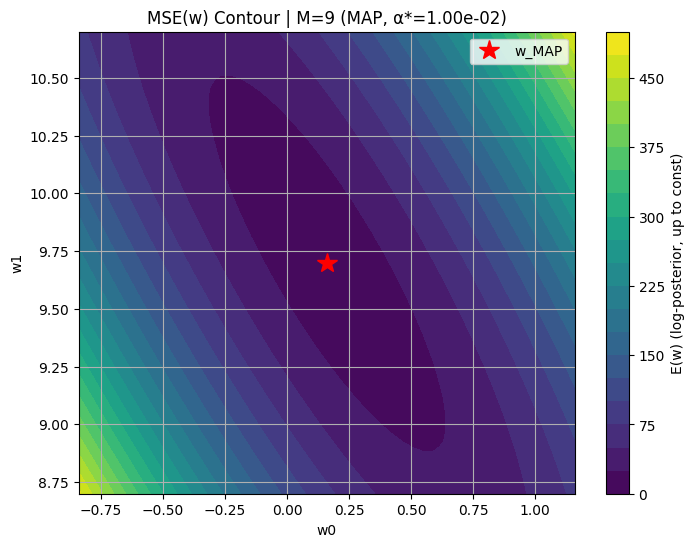

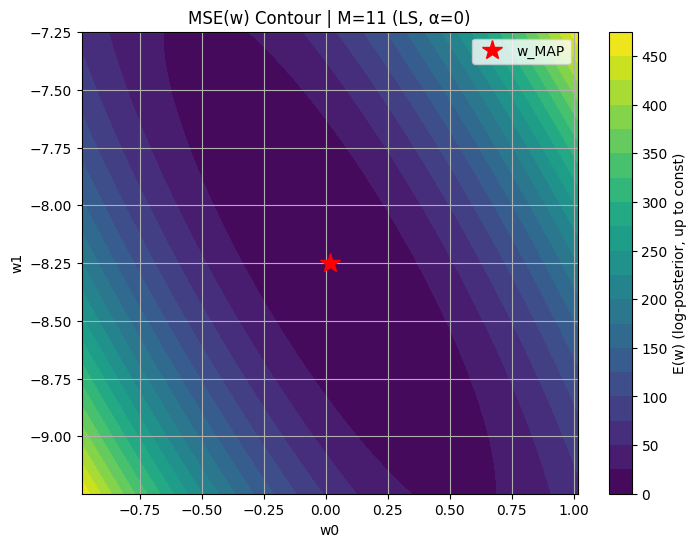

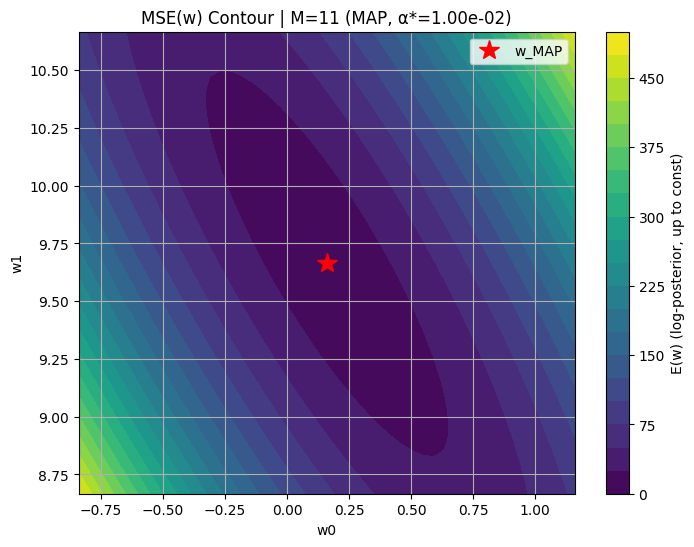

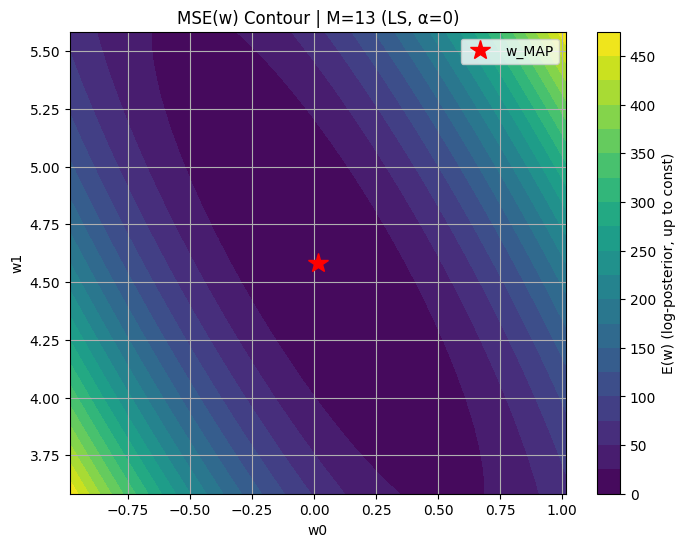

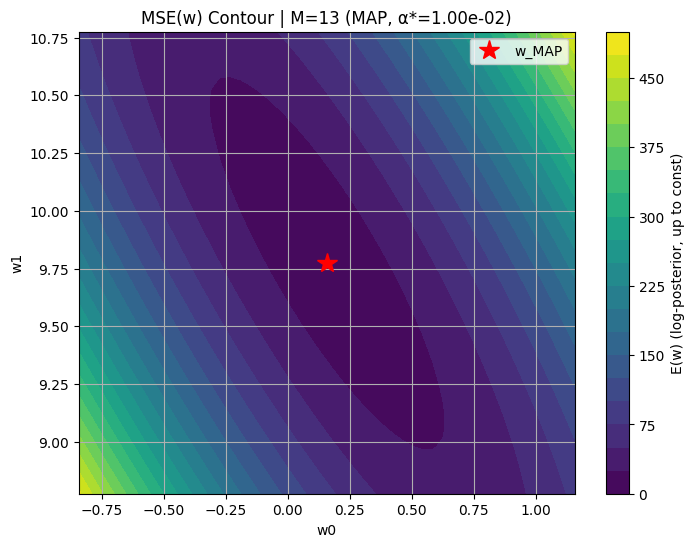

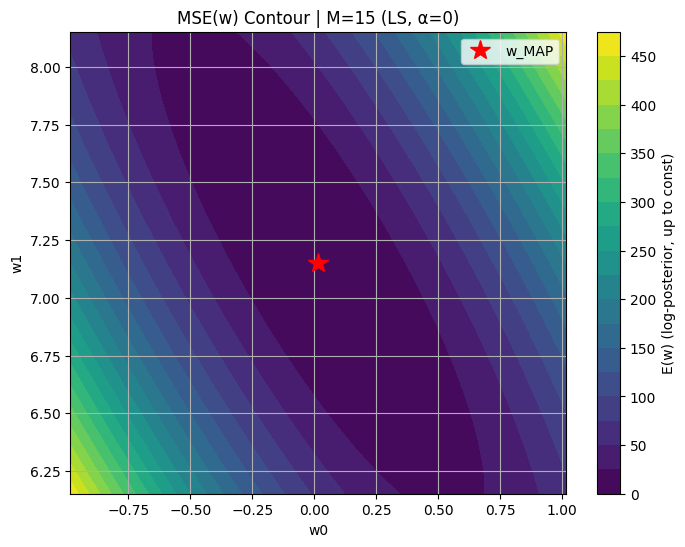

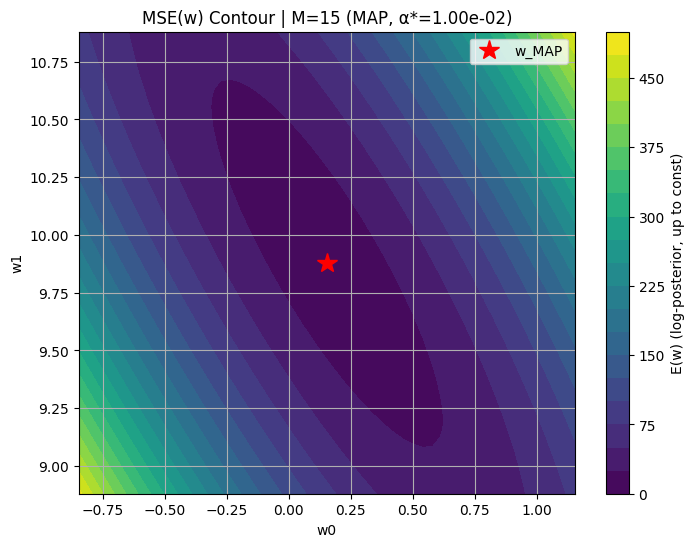

c:\Users\Mahdie\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\_lib\_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=2.27489e-18): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


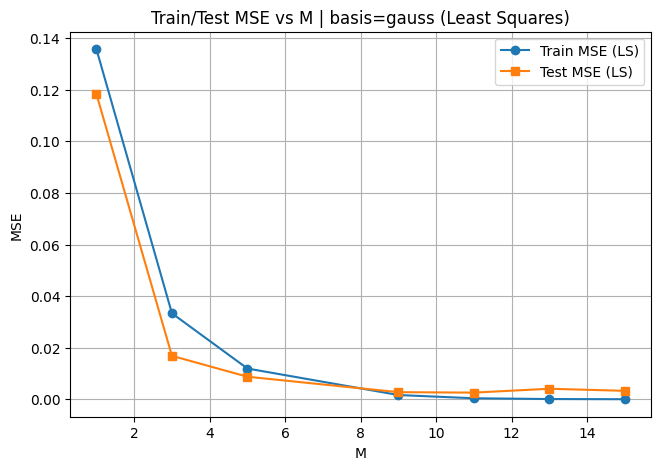

[basis=gauss] M_opt (min Test LS) = 11 | M_overfit = 13


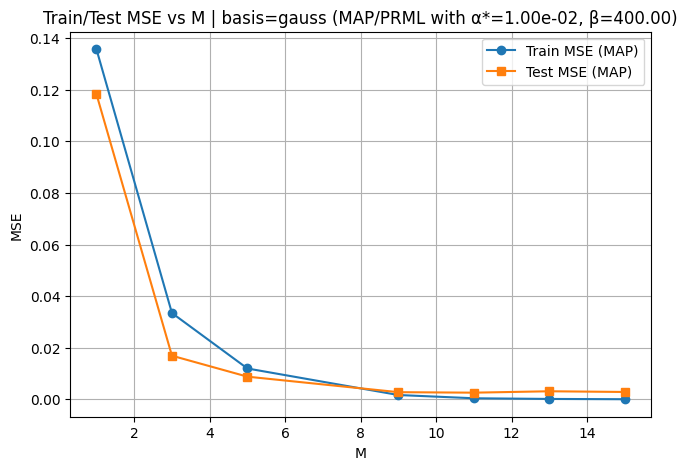

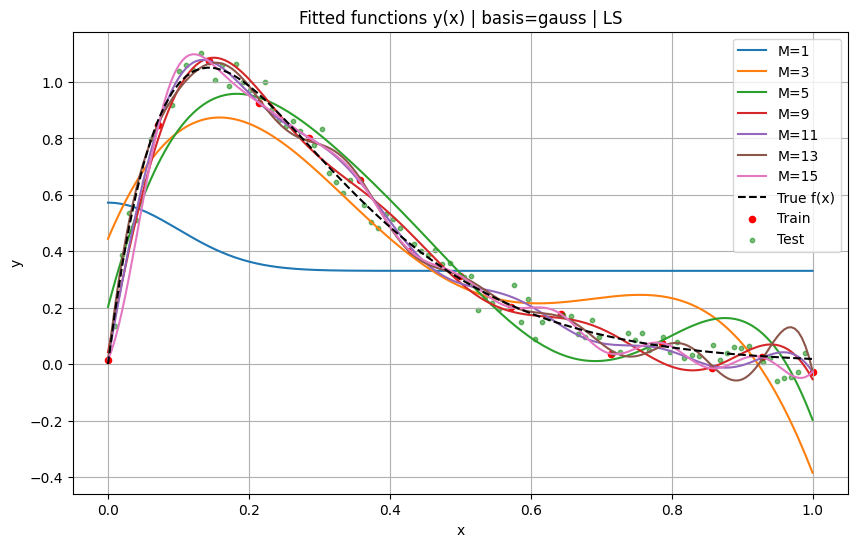

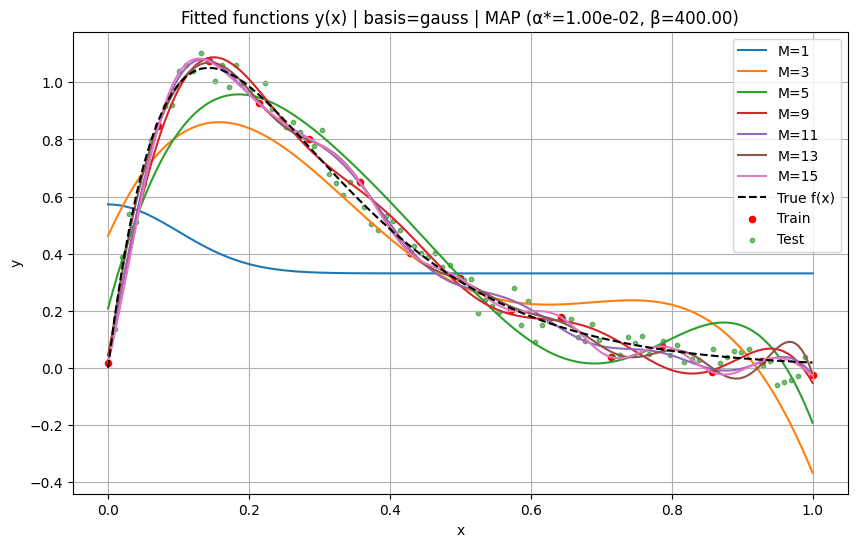

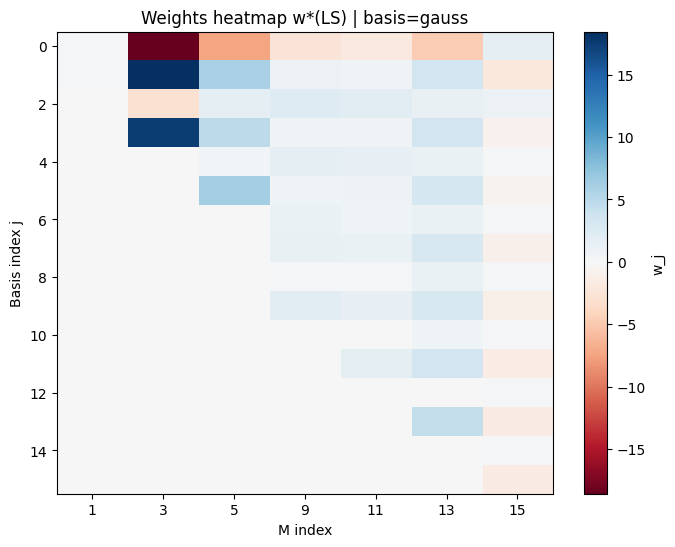

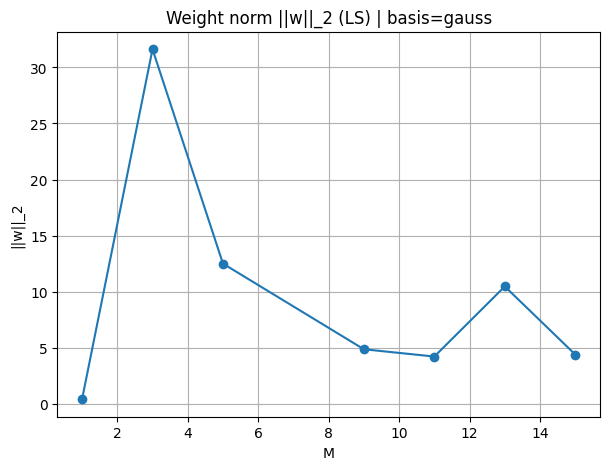

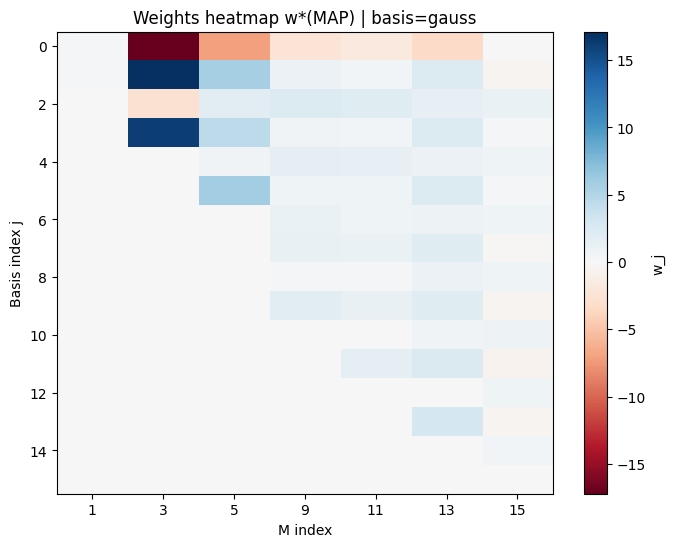

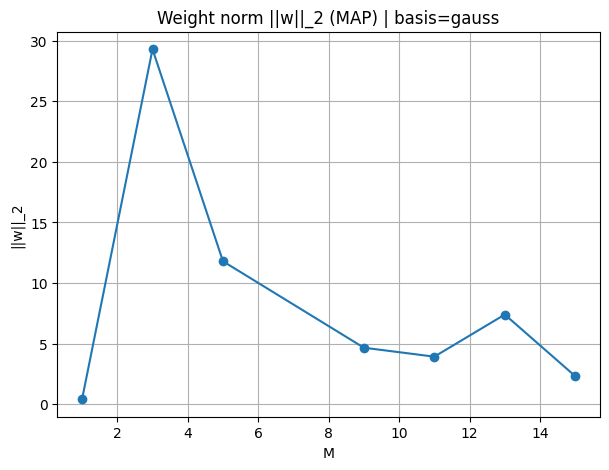

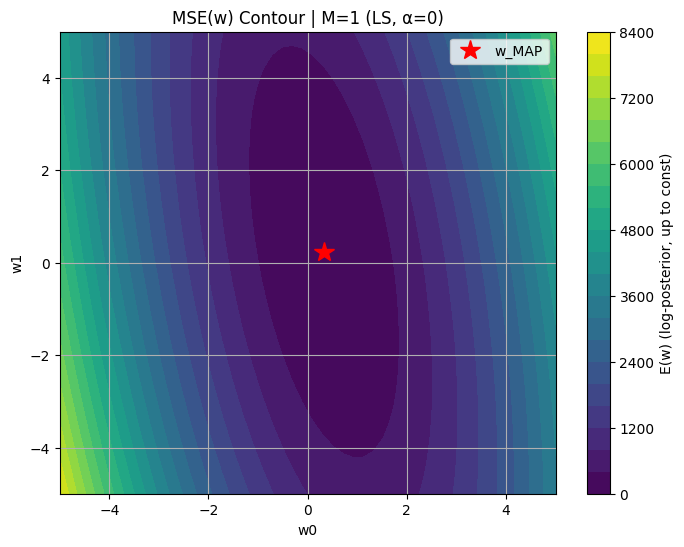

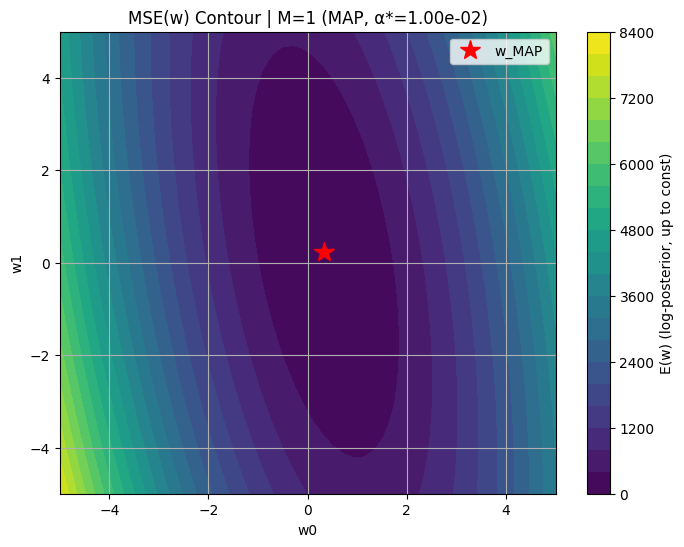

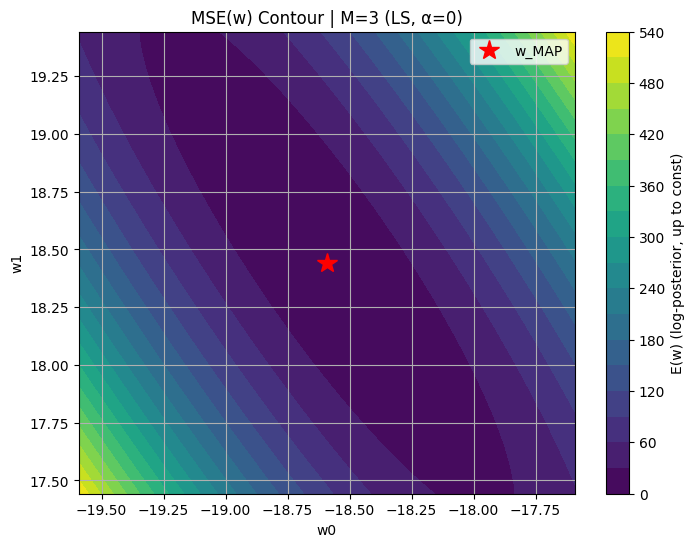

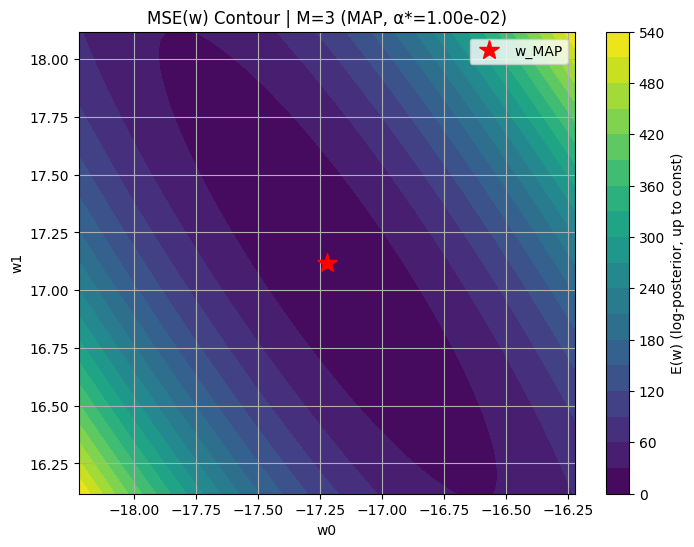

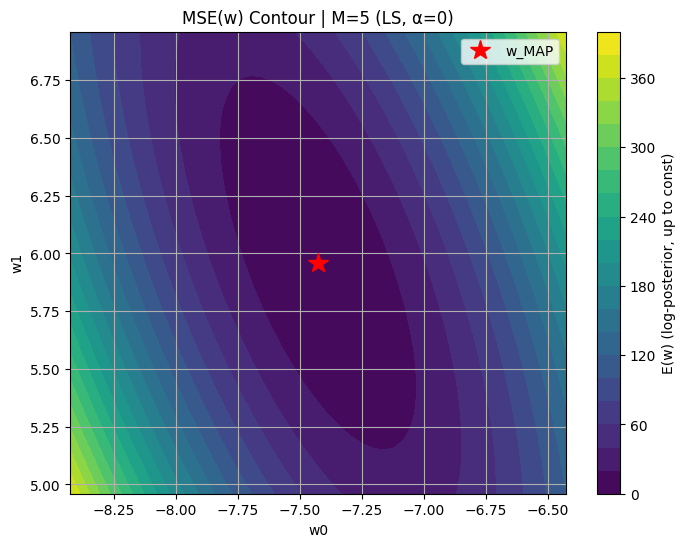

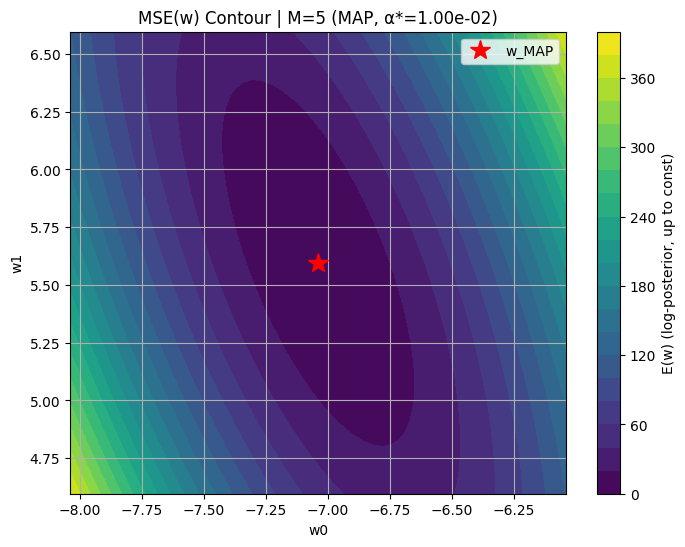

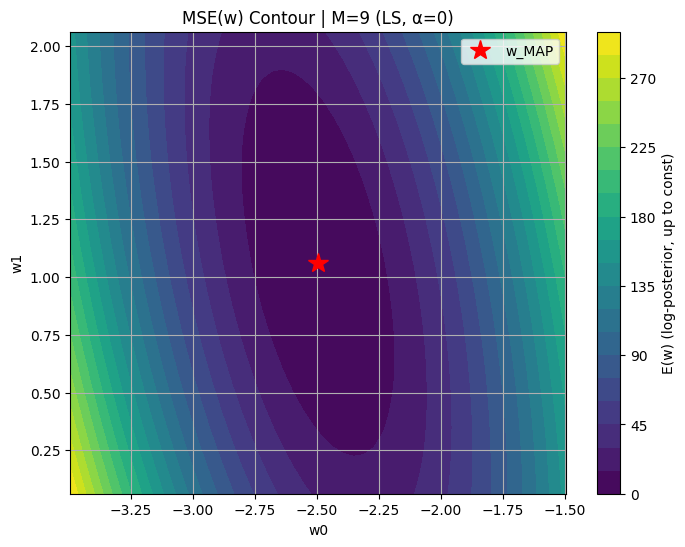

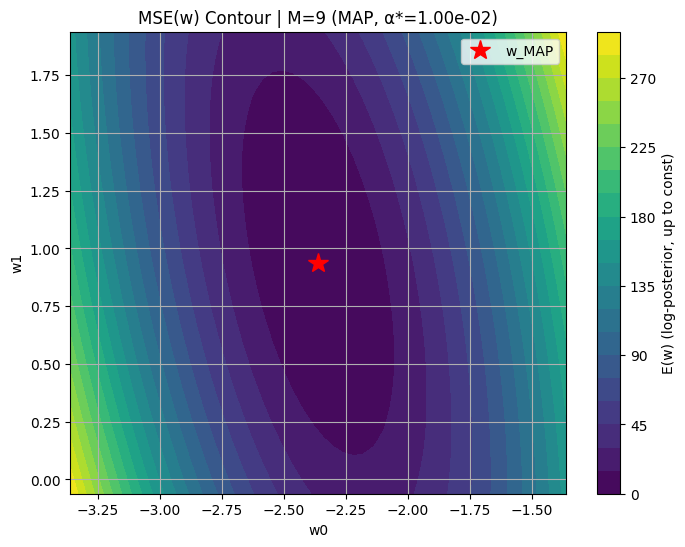

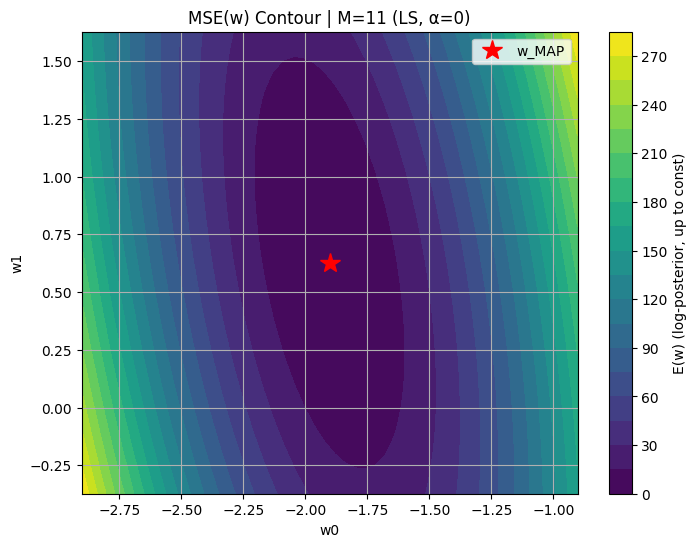

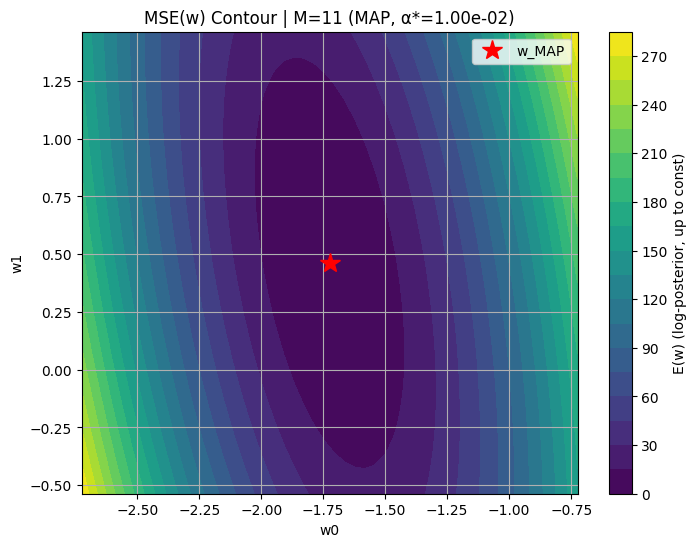

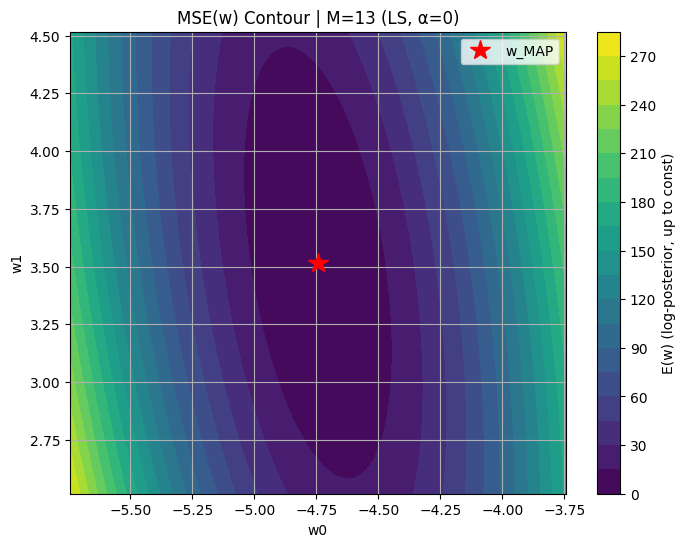

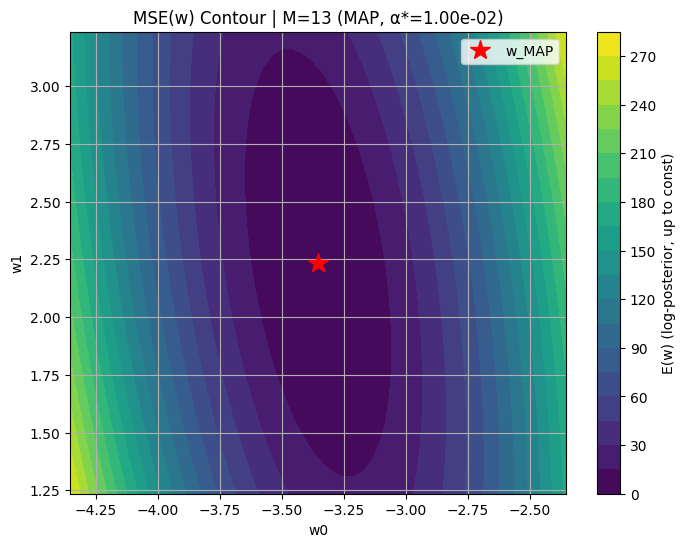

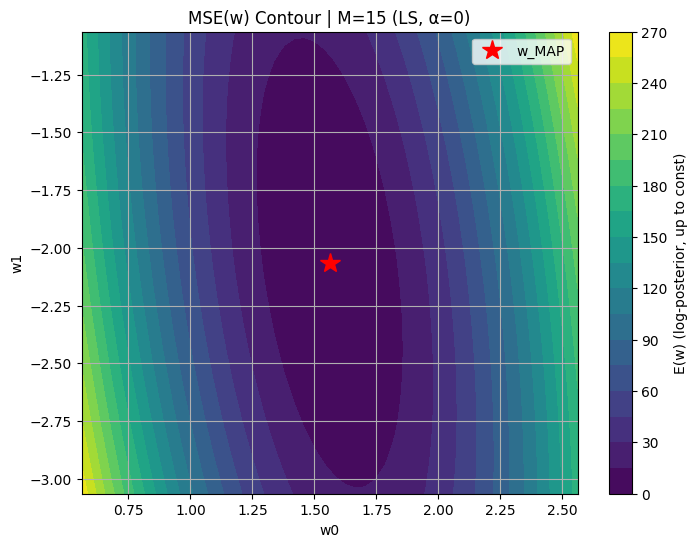

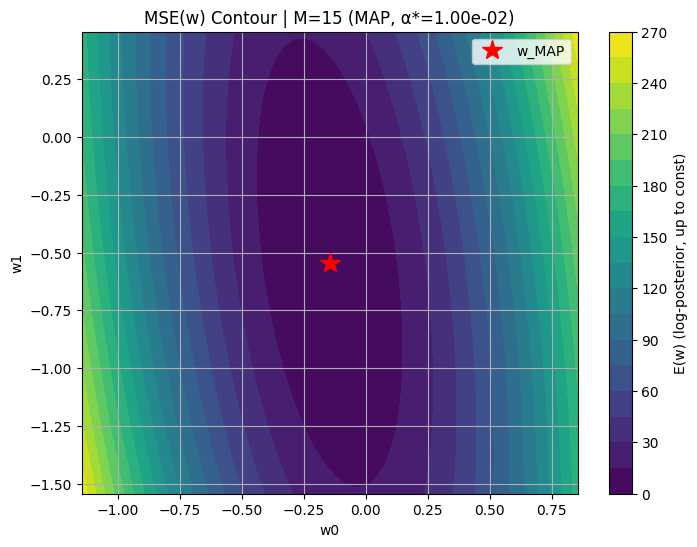

In [17]:
# Run the full experiment pipeline for both basis types
for basis_type in ["poly", "gauss"]:
    # Fit least squares models across all M values
    tr_ls, te_ls, w_ls, basis_params = run_ls_for_basis(basis_type)
    # Plot train/test MSE curves for least squares
    plt.figure(figsize=(7.5, 5))
    plt.plot(M_list, tr_ls, marker="o", label="Train MSE (LS)")
    plt.plot(M_list, te_ls, marker="s", label="Test MSE (LS)")
    plt.xlabel("M")
    plt.ylabel("MSE")
    plt.title(f"Train/Test MSE vs M | basis={basis_type} (Least Squares)")
    plt.grid(True)
    plt.legend()
    plt.show()
    # Pick the best-performing M on test set and a heuristic overfitting point
    M_opt, M_overfit = choose_M_overfit(tr_ls, te_ls)
    print(f"[basis={basis_type}] M_opt (min Test LS) = {M_opt} | M_overfit = {M_overfit}")
    # Fit MAP models across all M values using the fixed alpha*
    _, tr_map, te_map, w_map = run_map_for_basis(
        basis_type, M_overfit, basis_params, alpha_star_fixed, beta
    )
    # Plot train/test MSE curves for MAP
    plt.figure(figsize=(7.5, 5))
    plt.plot(M_list, tr_map, marker="o", label="Train MSE (MAP)")
    plt.plot(M_list, te_map, marker="s", label="Test MSE (MAP)")
    plt.xlabel("M")
    plt.ylabel("MSE")
    plt.title(
        f"Train/Test MSE vs M | basis={basis_type} "
        f"(MAP/PRML with α*={alpha_star_fixed:.2e}, β={beta:.2f})"
    )
    plt.grid(True)
    plt.legend()
    plt.show()
    # Package models in the format expected by the plotting helper
    models_ls = {M: (w_ls[M], basis_params[M]) for M in M_list if M in w_ls}
    models_map = {M: (w_map[M], basis_params[M]) for M in M_list if M in w_map}
    # Plot fitted functions for LS and MAP
    plot_fits(models_ls, basis_type, title=f"Fitted functions y(x) | basis={basis_type} | LS")
    plot_fits(
        models_map,
        basis_type,
        title=f"Fitted functions y(x) | basis={basis_type} | MAP (α*={alpha_star_fixed:.2e}, β={beta:.2f})"
    )
    # Inspect learned weights for LS
    plot_weight_heatmap(w_ls, M_list, title=f"Weights heatmap w*(LS) | basis={basis_type}")
    plot_weight_norms(w_ls, M_list, title=f"Weight norm ||w||_2 (LS) | basis={basis_type}")
    # Inspect learned weights for MAP
    plot_weight_heatmap(w_map, M_list, title=f"Weights heatmap w*(MAP) | basis={basis_type}")
    plot_weight_norms(w_map, M_list, title=f"Weight norm ||w||_2 (MAP) | basis={basis_type}")
    # Visualize the objective surface (in w0-w1 space) for each M under LS vs MAP
    for M in M_list:
        # Build the training design matrix for the selected basis
        if basis_type == "poly":
            Phi_tr_mse = design_matrix_poly(x_train, M)
        else:
            centers, sigma = basis_params[M]
            Phi_tr_mse, _, _ = design_matrix_gauss(
                x_train, M, centers=centers, sigma=sigma, include_bias=True
            )
        # Plot LS energy surface (alpha=0) around the LS solution
        w_ls_m = w_ls[M]
        plot_mse_surface(
            Phi_tr_mse, t_train, w_ls_m,
            alpha=0, beta=beta, M=M,
            title_suffix="(LS, α=0)"
        )
        # Plot MAP energy surface (alpha=alpha*) around the MAP solution
        w_map_m = w_map[M]
        plot_mse_surface(
            Phi_tr_mse, t_train, w_map_m,
            alpha=alpha_star_fixed, beta=beta, M=M,
            title_suffix=f"(MAP, α*={alpha_star_fixed:.2e})"
        )
    # Store results for later comparison / reporting
    all_results[basis_type] = {
        "train_mse_ls": tr_ls,
        "test_mse_ls": te_ls,
        "M_opt_ls": M_opt,
        "M_overfit": M_overfit,
        "alpha_star": alpha_star_fixed,
        "beta": beta,
        "train_mse_map": tr_map,
        "test_mse_map": te_map,
    }

# 18. MAP Regression with Variable Regularization Parameter


[basis=poly] Best M by MAP(alpha*(M)) on Test: M=9 | Test MSE=0.001628 | alpha*=7.318e-07

[basis=gauss] Best M by MAP(alpha*(M)) on Test: M=13 | Test MSE=0.002583 | alpha*=2.868e-01


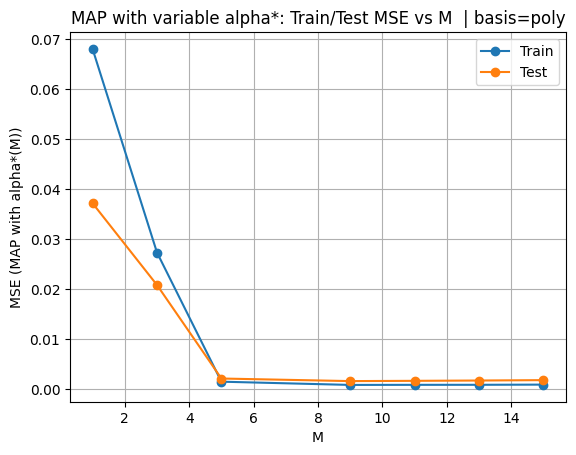

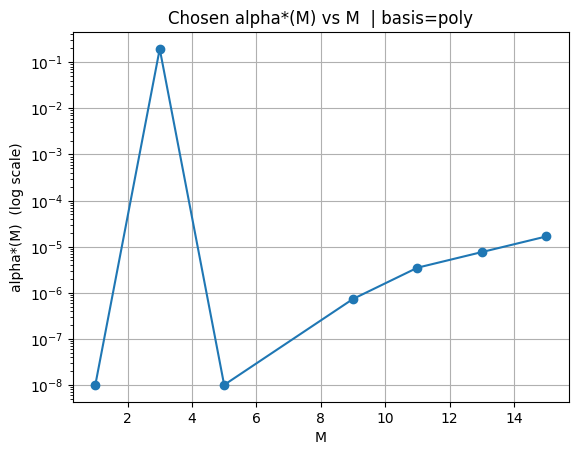

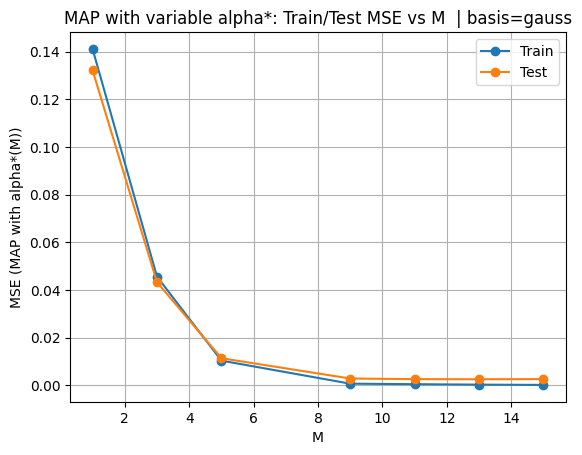

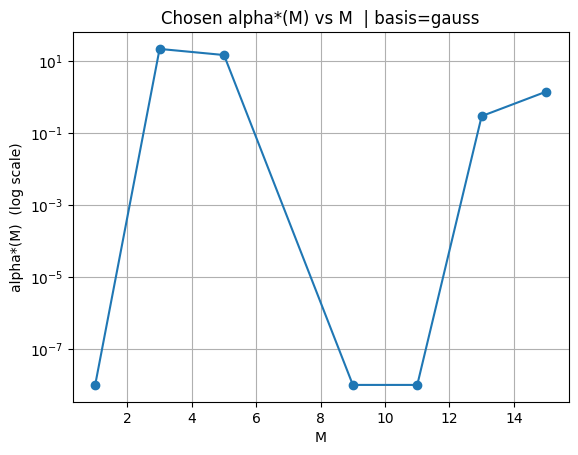

In [ ]:
alpha_grid = np.logspace(-8, 2, 60)
# Basis configurations (polynomial / gauss)
basis_configs = [
    {
        "basis_type": "poly",
        "basis_params": {}
    },
    {
        "basis_type": "gauss",
        "basis_params": {
            "centers": centers,   # predefined Gaussian centers
            "sigma": sigma        # Gaussian width
        }
    }
]
# Build design matrix Phi for a given basis and M
def build_design(basis_type: str, x, M: int, basis_params: dict):
    if basis_type == "poly":
        # Polynomial basis of degree M
        return design_matrix_poly(x, M)
    elif basis_type == "gauss":
        # Gaussian basis with the first M centers
        centers_full = basis_params["centers"]
        sigma = basis_params["sigma"]
        # Use only the first M centers to control model complexity
        centers_M = centers_full[:M]
        Phi, _, _ = design_matrix_gauss(
            x, M,
            centers=centers_M,
            sigma=sigma,
            include_bias=True
        )
        return Phi
    else:
        raise ValueError(f"Unknown basis_type: {basis_type}")
# Tune alpha* for a fixed M by minimizing Test MSE
def tune_alpha_star_for_M(
    basis_type: str,
    M: int,
    basis_params: dict,
    beta: float,
    alpha_grid: np.ndarray
):
    # Build design matrices
    Phi_tr = build_design(basis_type, x_train, M, basis_params)
    Phi_te = build_design(basis_type, x_test,  M, basis_params)
    best_alpha = None
    best_te = np.inf
    best_w = None
    # Grid search over alpha values
    for a in alpha_grid:
        w = fit_map(Phi_tr, t_train, a, beta)
        te = mse(Phi_te @ w, t_test)
        if te < best_te:
            best_te = te
            best_alpha = float(a)
            best_w = w
    # Compute Train MSE using the best alpha*
    tr = mse(Phi_tr @ best_w, t_train)
    return best_alpha, float(tr), float(best_te), best_w
# Run MAP with variable alpha* for all bases and all M
variable_alpha_results = {}
for cfg in basis_configs:
    basis_type = cfg["basis_type"]
    basis_params = cfg["basis_params"]
    alphas_star = []
    tr_map_star = []
    te_map_star = []
    w_map_star = {}
    # Loop over model complexities
    for M in M_list:
        a_star, tr, te, w = tune_alpha_star_for_M(
            basis_type=basis_type,
            M=M,
            basis_params=basis_params,
            beta=beta,
            alpha_grid=alpha_grid
        )
        alphas_star.append(a_star)
        tr_map_star.append(tr)
        te_map_star.append(te)
        w_map_star[M] = w
    # Store results for later analysis
    variable_alpha_results[basis_type] = {
        "alpha_star_per_M": np.array(alphas_star),
        "train_mse_map_star": np.array(tr_map_star),
        "test_mse_map_star":  np.array(te_map_star),
        "w_map_star": w_map_star
    }
    # Plot Train/Test MSE
    plt.figure()
    plt.plot(M_list, tr_map_star, marker='o')
    plt.plot(M_list, te_map_star, marker='o')
    plt.xlabel("M")
    plt.ylabel("MSE (MAP with alpha*(M))")
    plt.title(f"MAP with variable alpha*: Train/Test MSE vs M | basis={basis_type}")
    plt.legend(["Train", "Test"])
    plt.grid(True)
    # Plot alpha*(M)
    plt.figure()
    plt.semilogy(M_list, alphas_star, marker='o')
    plt.xlabel("M")
    plt.ylabel("alpha*(M) (log scale)")
    plt.title(f"Chosen alpha*(M) vs M | basis={basis_type}")
    plt.grid(True)
    # Print best M for this basis
    best_idx = int(np.argmin(te_map_star))
    print(
        f"\n[basis={basis_type}] Best M by MAP(alpha*(M)) on Test: "
        f"M={M_list[best_idx]} | Test MSE={te_map_star[best_idx]:.6f} "
        f"| alpha*={alphas_star[best_idx]:.3e}"
    )